# Week 3: Computational Linear Algebra and Principal Component Analysis  <span style="font-size: 0.3em;">v20260914a</span>

**Content:**
- Part 1: Understanding the basics of PCA
- Part 2: PCA on the Wine dataset
- Part 3: Hidden structure in handwritten digits
- (Optional) Part 4: $k$-nearest neighbors on reduced data (***Optional***) 
- [Assignment 3: PCA on Whisky data](#my-anchor)

**Objectives:**
- Get acquainted with how data can be filtered and visualized using principal component analysis (PCA).
- Learn how to do matrix operations and principal component analysis (PCA) by hand and with python. 
- Apply and interpret principal component analysis (PCA) for data visualization and dimensionality reduction / feature extraction.

## Commands and Methods Used in the Notebook

We will focus on two key libraries used for machine learning, namely **NumPy** (for arrays, math, and linear algebra) and **scikit-learn (sklearn)** (for applying standard ML algorithms). We will use **Pandas** and dataframes to load data and do light plotting. **scikit-learn (sklearn)** provides simple, consistent tools for training models and making predictions, so we can use established algorithms without implementing them from scratch.

The exercises use (or ask you to use) the following commands and methods:

- `pandas` (for loading and holding data)
  - `pd.read_csv`: load CSV data into a dataframe

- `numpy` (arrays + core numerical operations)
  - `np.load`: load `.npy` files
  - `np.mean`: average values
  - `np.argsort`: indices that would sort an array

- `numpy.linalg` (linear algebra)
  - `np.linalg.norm`: vector/matrix norm (magnitude / length)
  - `np.linalg.svd`: singular value decomposition (SVD)
  - `np.linalg.eigh`: eigenvalues/eigenvectors for symmetric (Hermitian) matrices

- `sklearn.neighbors` (classification)
  - `KNeighborsClassifier`: k-nearest neighbors classifier
    - `.fit()`: train the classifier
    - `.predict()`: make predictions

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting style
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

## Introduction

Data in the real world is typically **high-dimensional**, containing many collected attributes - as examples, you have already worked with images and the wine dataset. According to the **[manifold hypothesis](https://en.wikipedia.org/wiki/Manifold_hypothesis?utm_source=chatgpt.com)**, much of this data actually lies on a lower-dimensional manifold, meaning that the data can be explained in fewer dimensions - i.e. there is an **underlying structure that can be described with fewer dimensions**. Exploiting this structure allows us to remove redundant information in the data which in turn can help reduce computational and storage requirements as well as make high-dimensional data easier to visualize and interpret.

Using basic linear algebra, we can project data from its original high-dimensional space into a **lower-dimensional subspace**. The central question then becomes: what projection best preserves the structure of the data? In this week’s exercise, we explore one of the most widely used approaches to answering this question, namely Principal Component Analysis (PCA).

## Part 1: Understanding the basics of PCA

In this exercise, we will build intuition for PCA by constructing a simple toy example, recreating the PCA example of a Gaussian point cloud from the lecture slides. 

For intuition, we first generate a "high"-dimensional dataset that lie in a lower-dimensional space by:
1) generating $N=1000$ samples in $\mathbb{R}^2$ from a multivariate Gaussian distribution (more on that next week!). We store these points as $\boldsymbol{Z}$ of shape $N \times K$ ($1000 \times 3$).
2) embedding these points linearly in $\mathbb{R}^3$. We store the embedded points in our well-known data matrix $\boldsymbol{X}$ of shape $N \times M$ ($1000 \times 2$). 

We provide the code and visualize the point cloud in the cell below.


**Task 1.0:** Look at the plots, and convince yourself that the points in $\mathbb{R}^3$ actually lie on a 2-dimensional plane.

> *Hint:* Remember that you can add the magic `%matplotlib qt` in the beginning of the cell to open the plot in a separate window where you can interact with the 3D element. Remember to also revert to `%matplotlib inline` when done.

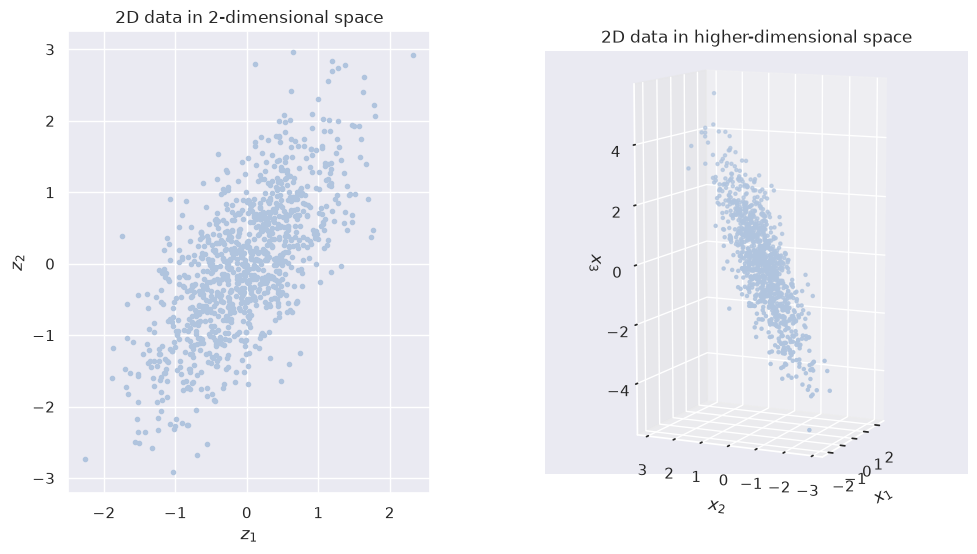

In [ ]:
%matplotlib inline

N = 1000
M = 3
K = 2

np.random.seed(42)

# Define the mean and covariance matrix for the 2D Gaussian
mu = np.array([0, 0])
Sigma = np.array([[0.5, 0.5], 
                  [0.5, 1.0]])

# Sample points from the 2D Gaussian
Z = np.random.multivariate_normal(mu, Sigma, N)

# Embed the points in the higher-dimensional space
X = np.hstack((Z, (Z[:, 0] + Z[:, 1])[:, np.newaxis])) # Add a third dimension as a linear combination of the first two

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121)
ax.set_title('2D data in 2-dimensional space')
ax.scatter(Z[:, 0], Z[:, 1], c='lightsteelblue', marker='.')
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
ax.set_aspect('equal')

ax = fig.add_subplot(122, projection='3d')
ax.view_init(elev=10, azim=-155)
ax.set_title('2D data in higher-dimensional space')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='lightsteelblue', marker='.')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_3$')
ax.set_aspect('equal')
plt.show()

PCA is a linear projection technique for reducing dimensionality by finding the directions (principal components) along which the data exhibits the **greatest variance**, thereby maximizing the variance captured in a low-dimensional subspace. As seen in the lecture, identifying these principal components $\left[\boldsymbol{v}_1, \boldsymbol{v}_2, \dots, \boldsymbol{v}_M\right]$ reduces to solving an eigenvalue problem:
$$
\underset{\boldsymbol{v}}{\arg \max}\ \mathrm{Var}[\boldsymbol{X}\boldsymbol{v}]
\quad \text{s.t.}\quad \lVert\boldsymbol{v}\rVert^2 = 1
\qquad \Rightarrow \qquad
\frac{1}{N-1}\tilde{\boldsymbol{X}}^\top \tilde{\boldsymbol{X}}\, \boldsymbol{v}_i
= \lambda_i \boldsymbol{v}_i .
$$
Here $\tilde{\boldsymbol{X}}=\boldsymbol{X}-\boldsymbol{\mu}$ is the centered data (normalized), and therefore
$$
\hat{\boldsymbol{S}}=\frac{1}{N-1}\tilde{\boldsymbol{X}}^\top \tilde{\boldsymbol{X}}
$$
is the estimated **covariance matrix** of the data. 


We can find the PCs as the eigenvectors of $\hat{\boldsymbol{S}}$, which we compute efficiently using singular value decomposition (SVD) ***directly*** on the centered data matrix:
$$
\tilde{\boldsymbol{X}} = \boldsymbol{U}\boldsymbol{\Sigma}\boldsymbol{V}^\top .
$$
The principal component directions (eigenvectors of $\tilde{\boldsymbol{X}}^\top\tilde{\boldsymbol{X}}$) are given by the columns of $\boldsymbol{V}$, i.e.
$$
\boldsymbol{V}_M=
\begin{bmatrix}
| & | & & |\\
\boldsymbol{v}_1 & \boldsymbol{v}_2 & \dots & \boldsymbol{v}_M\\
| & | & & |
\end{bmatrix},
$$
and $\boldsymbol{\Sigma}$ contains the singular values $\sigma_i$ on its diagonal. Using this, we can quantify how much variation each component accounts for via the corresponding covariance eigenvalue (the **explained variance**):
$$
\lambda_i = \frac{1}{N-1}\sigma_i^2 .
$$
Similarly, the fraction of explained variance for the $i$'th component is
$$
\rho_i=\frac{\lambda_i}{\sum_{j}\lambda_j}
=\frac{\frac{1}{N-1}\sigma_i^2}{\sum_{j}\frac{1}{N-1}\sigma_j^2}
=\frac{\sigma_i^2}{\sum_{j}\sigma_j^2}.
$$

Lastly, the projections $\boldsymbol{b}_i$ and reconstructions $\hat{\boldsymbol{x}}_i$ can be computed for a collection of data points as:
$$
\boldsymbol{B}=\tilde{\boldsymbol{X}}\boldsymbol{V}_K
\quad\text{and}\quad
\hat{\tilde{\boldsymbol{X}}}=\boldsymbol{B}\boldsymbol{V}_K^\top,
\qquad
\hat{\boldsymbol{X}}=\hat{\tilde{\boldsymbol{X}}}+\boldsymbol{\mu},
$$

Here, $K$ denotes the number of principal components retained (i.e., the target dimensionality of the projected space).

For real-world data with different units/scales, we typically standardize each feature before PCA to avoid components being dominated by measurement scale.

As you can see, PCA finds structure in observed data without using any target attribute and is therefore an **unsupervised learning** technique.



----

<br>

By following the above formulas, we can now define a function `compute_pca(X)` that returns the matrix of principal component directions `V` ($\boldsymbol{V}$), the vector of singular values `s` (the diagonal entries of $\boldsymbol{\Sigma}$), and the matrix of left singular vectors `U` ($\boldsymbol{U}$).

**Task 1.1:** Implement `compute_pca(X)` by filling in the missing lines in the function below.

- **Task 1.1.1:** Center the data, `X`, by subtracting the mean of each feature. Name the variable `X_tilde`.
    > *Hint:* Use `np.mean()`, be mindful of which axis you compute the mean on. 

- **Task 1.1.2:** Compute `U`, `s` and `V` through Singular Value Decomposition on the centered data matrix.
    > *Hint:* You can use `np.linalg.svd()` on your centered data matrix. <br> It returns $\boldsymbol{U}$, a list of singular values (Corresponding to the diagonal entries of $\boldsymbol{\Sigma}$) and the transposed principal directions, $\boldsymbol{V}^\top$. Save these as variables `U`, `s` and `Vt`.

    > *Hint:* Finally, remember to transpose `Vt` to get `V`.


In [ ]:
def compute_pca(X):
    # Task 1.1.1: Center the data, X, by subtracting the mean of each feature. Call the variable X_tilde.
    # YOUR CODE HERE
    raise NotImplementedError()
    
    # Task 1.1.2: Use np.linalg.svd on the centered data matrix, X_tilde, to compute (U, s, Vt) - then transpose Vt to get V.
    # YOUR CODE HERE
    raise NotImplementedError()

    return U, s, V    

**Task 1.2:** Compute the PCA and validate the output

- **Task 1.2.1:** Use your function on `X`, to compute `U`, `s` and `V`.

- **Task 1.2.2:** We compute the norms of and the angles between the column vectors in `V`. Inspect and validate that they form an orthogonal basis.
    > *Hint:* If the inner product between two vectors of length one is zero then they are orthogonal. If it is one then the angle between them is zero. 
    
    > *Note*: you will likely see some values very close to zero, but not exactly, due to nummerical precision of computers.


In [ ]:
# Task 1.2.1: Use compute_pca on the data matrix X to compute U, s, and V.

# Pretty print the important V and s vectors/matrices
print(f"V=\n{np.array2string(V)}")
print(f"\nSingular values:\n{np.array2string(s)}\n")
print(f"(Corresponding eigenvalues of the covariance matrix:\n{np.array2string(s**2 / (N-1))})")

# Task 1.2.2 (Inspect): Compute the norm of the (column) vectors
V_norms = np.linalg.norm(V, axis=0)

# Compute the inner product between vectors in a pairwise manner
V_dot = V.T @ V

# Print the norms and inner products
print("\nNorms of the three vectors in V: " + np.array2string(V_norms))
print("\nInner products between all vectors pairwise:\n" + np.array2string(V_dot))

<br>

**Task 1.3 (optional, advanced)** As we have eluded to above, an alternative approach to computing the PCA, is to compute the eigendecomposition of the covariance matrix. We outline this here to show you the connection between the SVD on the data matrix and the eigendecomposion (via SVD) on the covariance matrix

- **Task 1.3.1:** Center the data, `X`, by subtracting the mean of each feature. Name the variable `X_tilde`.
    > *Hint:* Use `np.mean()`, be mindful of which axis you compute the mean on. 

- **Task 1.3.2:** Compute the covariance matrix, $\hat{\boldsymbol{S}}$. Name the variable `S_hat`.
    > *Hint:* You can use `X_tilde.T` to transpose the centered data, and `@` for matrix-multiplication.

- **Task 1.3.3:** Compute `U`, `s` and `V` through Singular Value Decomposition on the covariance matrix, `S_hat`.
  > *Hint:* You can use `np.linalg.svd()` on your centered data matrix. <br> It returns $\boldsymbol{U}$, a list of eigenvalues of the covariance matrix and the transposed principal directions, $\boldsymbol{V}^\top$. Save these as variables `U`, `s` and `Vt`.

  > *Hint:* Finally, remember to transpose `Vt` to get `V`.

  > *Hint:* Computing SVD on the covariance matrix, rather than the centered data, will directly output the eigenvalues in `s`, rather than the singular values. 

  > *Note:* The eigenvalues are unique; however, the eigenvectors are only equivalent up to a change in sign.

In [ ]:
# Optional: Do PCA by computing the SVD on the covariance matrix (instead of the data matrix)
def compute_pca_covar(X):
    # Task 1.3.1: Center the data, X, by subtracting the mean of each feature. Call the variable X_tilde.
    # YOUR CODE HERE
    raise NotImplementedError()
    
    # Task 1.3.2: Use np.linalg.svd on the covariance matrix, S_hat, to compute (U, s, Vt) - then transpose Vt to get V.
    N = X.shape[0]
    # YOUR CODE HERE
    raise NotImplementedError()
    return U, s, V
    #return U, s, V, U_, s_, V_, S_hat_

# Compute the PCA usign the alternative way of computing the s and V matrices
U_covar, s_covar, V_covar = compute_pca_covar(X)
print("V=\n" + np.array2string(V_covar))
print("\nEigenvalues of covariance matrix:" + np.array2string(s_covar))

In Task 1.3 we computed PCA by running SVD on the covariance matrix. Another common (and very direct) approach is to compute the **eigenvalues and eigenvectors** of the covariance matrix explicitly.

**Task 1.4 (optional, advanced)**: PCA via eigendecomposition with `np.linalg.eigh`
>  *Note:* Eigenvectors are only unique up to a sign flip, so your eigenvectors may differ from the SVD approach by a factor of \(-1\) in some columns—this is still correct.

- **Task 1.4.1:** Center the data matrix `X` by subtracting the mean of each feature.
    > *Hint:* Use `np.mean()`, be mindful of which axis you compute the mean on. 

- **Task 1.4.2:** Compute the covariance matrix, $\hat{\boldsymbol{S}}$. Name the variable `S_hat`.
    > *Hint:* You can use `X_tilde.T` to transpose the centered data, and `@` for matrix-multiplication.

- **Task 1.4.3:** Compute eigenvalues and -vectors using `e, V = np.linalg.eigh(S_hat)`. Remember to sort them in descending order. 
    > *Hint:* Use `np.linalg.eigh(S_hat)` to compute eigenvalues and eigenvectors.
    > *Hint:* Use `np.argsort(e)[::-1]` to obtain indices that sort `e` in descending order.
    > *Note:* `eigh` is not guaranteed to output the eigenvalues (and associated eigenvectors) in descending order.

In [ ]:
# Optional: Do PCA by computing by using the np.linalg.eig function to compute the eigenvectors and -values
def compute_pca_eig(X):
    # Task 1.4.1: Center the data, X, by subtracting the mean of each feature. Call the variable X_tilde.
    # YOUR CODE HERE
    raise NotImplementedError()
    
    # Task 1.4.2: Use np.linalg.eigh on the covariance matrix, S_hat, to compute (U, s, Vt) - then transpose Vt to get V.
    # Hint: remember to sort the output of eigh according to the eigenvalues descending order e.g. usign argsort
    N = X.shape[0]
    # YOUR CODE HERE
    raise NotImplementedError()

    # Task 1.4.3: Compute eigenvalues and -vectors using `e, V = np.linalg.eigh(S_hat)`. Remember to sort them in descending order. 
    # YOUR CODE HERE
    raise NotImplementedError()
        
    return V,e

# Compute the PCA usign the alternative way of computing the s and V matrices
V_eig, e_eig = compute_pca_eig(X)
print("V=\n" + np.array2string(V_eig))
print("\nEigenvalues of the covarince matrix:" + np.array2string(e_eig))

---

**Task 1.5:** We consider the solution fuond by `compute_pca(X)`. Using the first $K=2$ principal directions (the first two columns of `V`), compute the 2D principal components, `B`, by projecting the **centered** data matrix, `X_tilde`, onto this subspace.

> *Hint:* Center the data `X`, save it as `X_tilde`.

> *Hint:* Once you have your centered data matrix, you can compute the projections, $\boldsymbol{B}=\tilde{\boldsymbol{X}}\boldsymbol{V}_K$. Use `@` for matrix multiplication.

In [ ]:
# Dimensionality of projections
K = 2
# Slicing V to get first two principal directions
V_K = V[:, :K] 

# Task 1.5: Get the projections, B_K, by projecting X_tilde onto V_K
# YOUR CODE HERE
raise NotImplementedError()

Now that we have computed the first ($K=2$) principal component directions ($\boldsymbol{V}_K$) and projected the centered data onto them, we can visualize both the original data and its low-dimensional representation. The left panel shows the data in the original feature space (here 3D), together with the first two **principal component directions** (the first two columns of $\boldsymbol{V}$), drawn as arrows from the origin. The right panel shows the corresponding 2D projection,

$$\boldsymbol{B}_K=\tilde{\boldsymbol{X}}\boldsymbol{V}_K,$$

where each point is the same sample expressed in the coordinate system spanned by PC1 and PC2. In this projected space the coordinate axes align with the principal components, and the spread of the points along each axis reflects how much variance is captured by that component.

This ties back to how the dataset was constructed: although the points live in ($\mathbb{R}^3$), they were created by linearly embedding a 2D Gaussian, so the cloud lies (approximately) on a 2D plane. PCA recovers this underlying 2D structure by identifying the plane of maximal variance and representing the data using just two coordinates, illustrating the manifold hypothesis in this simple linear setting.


In [ ]:
# Define colors for the principal components
colors = ['red', 'darkgreen', 'orange']

# Create figure and subplot for high-dimensional data
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection='3d')
ax.set_title('Data in higher-dimensional space')
ax.view_init(elev=10, azim=-155) # viewing parameters

# Plot the high dimensional data, X - and the principal components, V_K, as lines. 
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='lightsteelblue', marker='.')
# Plot lines indicating the principal components
for i, pc in enumerate(V_K.T):
    ax.plot([0, pc[0]], [0, pc[1]], [0, pc[2]], color=colors[i], lw=3, label=f'PC{i+1}', zorder=5-i)

# Figure layout
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$z$')
ax.set_aspect('equal')
ax.legend()

# Create subplot for projected data
ax = fig.add_subplot(122)
ax.set_title('Data projected to lower-dimensional space')

# Plot the projected data, B, in 2D - along with the principal components in the projected space (which are just the standard basis vectors in 2D).
ax.scatter(B_K[:, 0], B_K[:, 1], c='lightsteelblue', marker='.')
# Plot lines indicating the principal components in the projected space
for i, pc in enumerate(np.eye(2)): # The projected PCs are just the standard basis in 2D
    ax.plot([0, pc[0]], [0, pc[1]], color=colors[i], lw=3, label=f'PC{i+1}', zorder=5-i)

# Figure layout
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_aspect('equal')
ax.legend()

plt.tight_layout()
plt.show()

We will now project a new data point, $
\boldsymbol{x}_{\text{new}} =
\begin{bmatrix}
1\\
2\\
3
\end{bmatrix}
\in \mathbb{R}^3
$, onto the 2-dimensional PCA subspace spanned by the first $K=2$ principal component directions, i.e. the columns of $\boldsymbol{V}_K$.

**Task 1.6.1:** *(Pen and paper)* Compute the 2D projection (the PCA coordinates) of $\boldsymbol{x}_{\text{new}}$:
$$
\boldsymbol{b}_{\text{new}} = (\boldsymbol{x}_{\text{new}} - \boldsymbol{\mu})^\top \boldsymbol{V}_K \in \mathbb{R}^2.
$$
(You may assume that $\boldsymbol{\mu}$ and $\boldsymbol{V}_K$ are known from the previous tasks.)

> *Hint:* Feel free to round the entries of $\boldsymbol{V}_K$ to a few decimals to simplify the arithmetic. Just be sure you understand the matrix multiplication steps.

**Task 1.6.2:** Compute the same 2D projection in code to check your answer.

In [ ]:
x_new = np.array([1, 2, 3])

# Task 1.6.2: Get the projection of x_new onto the first K principal components, b_new, by centering x_new and then projecting onto V_K.
# YOUR CODE HERE
raise NotImplementedError()

print(f"b_new = {b_new}")

<br>

Recall that $\boldsymbol{\Sigma}$ (computed by taking the SVD on the data matrix) contains the singular values $\sigma_i$ on its diagonal. Using this, we can quantify how much variation each component accounts for via the corresponding covariance eigenvalue (the **explained variance**):
$$
\lambda_i = \frac{1}{N-1}\sigma_i^2 .
$$

Similarly, the fraction of explained variance for the $i$'th component is

$$
\rho_i=\frac{\lambda_i}{\sum_{j}\lambda_j}
=\frac{\frac{1}{N-1}\sigma_i^2}{\sum_{j}\frac{1}{N-1}\sigma_j^2}
=\frac{\sigma_i^2}{\sum_{j}\sigma_j^2}.
$$

**Task 1.7:** Using the singular values from `s`, compute the **explained variance** for each of the ($M=3$) principal components, the corresponding **explained variance ratio** (fraction of total variance), and the **cumulative explained variance ratio** across components. <br> Save them as `lambddas`, `rhos`, `rhos_accumulated`.

> *Hint:* The elements in `s` are the singular values, $\sigma_{i}$. Use `s` to compute `lambdas`

> *Hint:* As evident in the formula of $\rho_i$, the $\left( N-1 \right)$ cancels out. 

> *Hint:* Use `np.cumsum()` to accumulate values of a numpy array.

In [ ]:
N = len(X)

# Task 1.7: Compute the explained variance, explained variance ratio, and cumulative explained variance ratio.
# Save them as lambdas, rhos, and rhos_accumulated, respectively.
# YOUR CODE HERE
raise NotImplementedError()

Now that we have computed the explained variance $\{\lambda_i\}_{i=1}^M$ and the explained variance ratios $\{\rho_i\}_{i=1}^M$, we can visualize how much of the dataset’s variance is captured by each principal component. The left plot shows the **explained variance** per component (the eigenvalues of the covariance matrix), while the right plot shows the **ratio of explained variance** (individual) together with the **cumulative** ratio as we include more components.

In [ ]:
from matplotlib.ticker import MaxNLocator, PercentFormatter

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

# --- Left: Explained variance (eigenvalues) ---
axs[0].bar(np.arange(1, M + 1), lambdas)
axs[0].set_title("Explained variance (per component)")
axs[0].set_xlabel("Principal component")
axs[0].set_ylabel("Explained variance")
axs[0].set_xticks(np.arange(1, M + 1))  # force integer ticks PC1..PCM
axs[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# --- Right: Explained variance ratio (individual + cumulative) ---
axs[1].plot(np.arange(1, M + 1), rhos, marker="x")
axs[1].plot(np.arange(1, M + 1), np.cumsum(rhos), marker="o")
axs[1].set_title("Explained variance ratio")
axs[1].set_xlabel("Principal component")
axs[1].set_ylabel("Fraction of total variance")
axs[1].set_xticks(np.arange(1, M + 1))
axs[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[1].set_ylim(0, 1.05)
axs[1].yaxis.set_major_formatter(PercentFormatter(xmax=1))  # show 0–100%

axs[1].legend(["Individual", "Cumulative"], loc="best")

plt.tight_layout()
plt.show()


As you will be able to tell from the plot, the first two principal components are able to explain **ALL** the variance of our 3-dimensional data.

**Task 1.8:** Using the explained variance figures, argue how we can see that all the observed data from $\mathbb{R}^3$ lie on a lower-dimensional subspace in $\mathbb{R}^2$.

- *Answer:*


---
## Part 2: PCA on the Wine dataset

The first real dataset we will do Principal Component Analysis on is the Wine dataset that you also saw last week.
We start by loading the data, remove outliers and then standardize the data as the attributes are on very different scales.

In [ ]:
df = pd.read_csv('data/wine.csv')

# Split into X and y
X = df.drop(columns=['Color', "Quality score (0-10)"])
y = df['Color']

assert X.shape == (6497, 11), "There should be 6497 samples and 11 features in the wine dataset"
assert y.shape == (6497,), "There should be 6497 labels in the wine dataset"

# Get the boolean mask for outlier detection
mask = (X['Volatile acidity'] > 2) | (X['Density'] > 1) | (X['Alcohol'] > 20)

# Remove outliers with conditional filtering
X = X[~mask]
y = y[~mask]

# Standardize the features in X by centering and scaling
X_mean = X.mean()
X_std = X.std()
X = (X - X_mean) / X_std

X.head()

The data resides in an 11-dimensional space where each dimension corresponds to each of the 11 physiochemical and sensory attributes. This makes visualization of the raw data difficult, because it is difficult to visualize data in more than 2-3 dimensions.

**Task 2.1:**  Plot the two attributes `Alcohol` and `pH` against each other in a scatter plot and color by the wine color, `y`. What do you see? Try to change the dimensions that are plotted against each other.

> *Hint:* Remember that you can use the inherent plotting functionalities of Pandas dataframes! `X.plot(kind='scatter', x=..., y=..., c=y, colormap='viridis')`.

In [ ]:
# Task 2.1: Create a scatter plot of the 'Alcohol' and 'pH' features in X, colored by the labels in y.
# YOUR CODE HERE
raise NotImplementedError()

**Task 2.2:** Compute the PCA of the Wine data, and calculate the explained variance ratios and cumulative explained variance. Save as `rhos` and `rhos_accumulated`.

> *Hint:* Use `compute_pca(X)` to get `s`, you can use this to find the explained variance ratios, $\boldsymbol{\rho}$.

> *Hint:* See **Tasks 1.2** and **1.7**.

In [ ]:
# Task 2.2: Compute the PCA of the Wine data, 
# and calculate the explained variance ratios and cumulative explained variance. 
# Save as `rhos` and `rhos_accumulated`.

# YOUR CODE HERE
raise NotImplementedError()

We have plotted the explained variance in the plot below, as well as a $90\%$ threshold. 

In [ ]:
# 90% threshold for variance explained
threshold = 0.9

# Plot variance explained
plt.figure()
plt.plot(range(1, len(rhos) + 1), rhos, "x-")
plt.plot(range(1, len(rhos) + 1), rhos_accumulated, "o-")
plt.plot([1, len(rhos)], [threshold, threshold], "k--")
plt.title("Variance explained by principal components")
plt.xlabel("Principal component")
plt.ylabel("Variance explained")
plt.legend(["Individual", "Cumulative", "Threshold"])
plt.grid()
plt.show()

**Task 2.3:** How many principal components do we need to explain more than $90\%$ of the variation in the data? How many components would be needed for 95%?

- *Answer:*

**Task 2.4** Project the data onto the first and second principal component, and save the projections as `B`. Plot the projections in a scatter plot, colored by the wine-color. 

> *Hint:* Use `PC_idxs` to index `V` before applying the projection to `X`.

> *Hint:* The `mask` is a boolean array with `True` when elements in `y == fluid_type`. 

In [ ]:
PC_idxs = [0, 1]  # Indices of the principal components to plot

# Project the data onto the first two principal components and plot, colored by their fluid type.

# Task 2.4: Project the data onto the first two principal components.
# YOUR CODE HERE
raise NotImplementedError()

unique_classes = np.unique(y) # Get unique classes from the target variable

# Wine-ish categorical colors
color_map = {"Red": "#8B0000", "White": "#F2E9C9"}  # deep red + straw/white-wine

# Plot PCA of the data
fig = plt.figure()
plt.title("Wine data: PCA")
# Plot the data projected onto the principal components, colored by their fluid type
for fluid_type in unique_classes:
    # Task 2.4: Create a mask on y for the current fluid type, save as mask.
    # YOUR CODE HERE
    raise NotImplementedError()

    # Plot the data for the current fluid type
    plt.plot(
        B.iloc[mask, 0], B.iloc[mask, 1],
        ".",
        color=color_map.get(fluid_type, "gray"),
        alpha=0.6,
        label=str(fluid_type)
    )

# Set axis labels
plt.xlabel(f"PC{PC_idxs[0] + 1}")
plt.ylabel(f"PC{PC_idxs[1] + 1}")

# Show legend only once per class (avoid duplicates if any)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Wine type")

plt.grid(True)
plt.tight_layout()
plt.show()

**Task 2.5:** What are the benefits of visualizing the data by the projection given by PCA over plotting two of the original data dimensions against each other?
- *Answer:*

As your previous result should reveal, the first 3 components explain roughly $60\%$ of the variance. To better understand what they tell us about the data, we will take a look at their coefficients.

In [ ]:
bw = 0.2
r = np.arange(1, X.shape[1] + 1)

fig = plt.figure(figsize=(10, 6))
plt.title("Wine: PCA Component Coefficients")

for i, pc in enumerate(V[:, :3].T):
    plt.bar(r + i * bw, pc, width=bw, label=f"PC{i+1}")

plt.xticks(r + bw, X.columns, rotation=45, ha="right")
plt.xlabel("Attributes")
plt.ylabel("Component coefficients")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


**Task 2.6:** Which of the original attributes does the second principal component mainly capture the variation of and what would cause an observation to have a large negative/positive projection onto the second principal component?

> *Hint:* remember that both the attributes and the prinpal component has a sign and a magnitude.

- *Answer:*

Another way to approach interpreting the principal directions is to plot the coefficients as vectors in the principal component space. In the PC1/PC2-space, we can for instance interpret the relationship between PC1, PC2 and a given attribute by drawing a line form Origo to the coefficients in PC1 and PC2 corresponding to the attribute. The direction and magnitude of such a vector defines how the data from that attribute is projected onto the PC1/PC2-space - e.g. if the vector points in positive direction of PC1, then positive values of that attribute contributes to a positive projection onto PC1. Since the vectors in $\boldsymbol{V}$ are unit-vectors, all coefficients will lie within the unit-circle.

We plot the dataset in the PC1/PC2 space alongside the accumulated explained variance ratio as well as the attribute coefficient vectors from the PCA loadings, showing their direction and magnitude within the unit circle to interpret how each attribute contributes to the principal components.

In [ ]:
# Make the plot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# Plot the data projected onto PC1/PC2
axs[0].set_title("Wine data: PCA")
for fluid_type in unique_classes:
    mask = (y.to_numpy() == fluid_type)
    axs[0].plot(B.iloc[mask, PC_idxs[0]], B.iloc[mask, PC_idxs[1]], ".", color=color_map.get(fluid_type, "gray"), alpha=0.6, label=fluid_type)

axs[0].set_xlabel(f"PC{PC_idxs[0] + 1}")
axs[0].set_ylabel(f"PC{PC_idxs[1] + 1}")
axs[0].axis("equal")

# Plot the explained variance ratio
axs[1].set_title("Accumulated explained variance ratio")
axs[1].plot(range(1, len(rhos_accumulated) + 1), rhos_accumulated)
axs[1].set_xlabel("Principal component")
axs[1].set_ylabel("Explained variance ratio")

# Plot attribute coefficients in principal component space
axs[2].set_title("Attribute coefficients in PC space")
for attr_idx, attr_name in enumerate(X.columns):
    # Plot an arrow for each attribute, add a label
    axs[2].arrow(0, 0, V[attr_idx, PC_idxs[0]], V[attr_idx, PC_idxs[1]], color='black', alpha=0.5)
    axs[2].text(V[attr_idx, PC_idxs[0]], V[attr_idx, PC_idxs[1]], attr_name)    
    
axs[2].set_xlim([-1, 1])
axs[2].set_ylim([-1, 1])
axs[2].set_xlabel(f"PC{PC_idxs[0] + 1}")
axs[2].set_ylabel(f"PC{PC_idxs[1] + 1}")
axs[2].grid()
# Add a unit circle
axs[2].plot(np.cos(np.arange(0, 2 * np.pi, 0.01)), np.sin(np.arange(0, 2 * np.pi, 0.01)))
axs[2].axis("equal")

plt.tight_layout()
plt.show()


---
## Part 3: Hidden structure in handwritten digits

The US Postal Service (USPS) wanted to automate the process of sorting letters based on their zip-codes. We will presently consider the dataset of USPS handwritten 
digits that we also worked with last week for information retrieval. Recall that the images are $16\times 16$ pixel images stored as $256$-dimensional (flattened) arrays. We have created a training and test set split of the data and provided it in the associated data folder.

We load the data:

In [ ]:
# Load files
traindata = np.load("data/digits/train_data.npy")
testdata = np.load("data/digits/test_data.npy")

# Separate into X and y
X_train, y_train = traindata[:, 1:], traindata[:, 0]
X_test, y_test = testdata[:, 1:], testdata[:, 0]

# Check the shape of the data
assert X_train.shape == (7291, 256), "Training data should have 7291 samples and 256 features"
assert y_train.shape == (7291,), "Training labels should have 7291 samples"
assert X_test.shape == (2007, 256), "Test data should have 2007 samples and 256 features"
assert y_test.shape == (2007,), "Test labels should have 2007 samples"

And visualize 3 images of each digit from the training set in a subplot.

In [ ]:
# Number of images per digit
show_n_digits = 3
# Get the list of unique digits
unique_digits = np.unique(y_train)

# Setup figure
fig, axs = plt.subplots(show_n_digits, len(unique_digits), figsize=(len(unique_digits)*2, show_n_digits*2))

# Iterate through the unique digits
for j, digit in enumerate(unique_digits):
    # Create a mask for the current digit
    mask = (y_train == digit)
    # Get the images for the current digit
    X_train_digit = X_train[mask]
    for i in range(show_n_digits):
        # Show the image
        axs[i,j].imshow(X_train_digit[i].reshape(16, 16), cmap="gray")
        axs[i,j].set_title(f"Label: {digit:.0f}")
        axs[i,j].axis("off")
        if i == 0:
            axs[i,j].set_title(f"Digit: {digit:.0f}")
plt.show()

The images live in a $M = 256$ dimensional vector space, where each dimension corresponds to a pixel. With PCA, we can project this high-dimensional data into a lower-dimensional subspace that preserves most of the variance and allows us to more easily compare the images while also removing potential noise in the handwritten digits.

**Task 3.1:** Compute a PCA on the training data. Show that it requires $K=55$ PCA components to account for more than $90$% of the variance in the data. Plot an explained variance vs. number of components plot, like you've done before.

> *Hint:* Plot the explained variance ratio and a 90% threshold.

> *Hint:* Create a boolean array, that determines whether the cumulative variance is above 90%.

> *Hint:* You can find the index of the first true element of a boolean array with `np.argmax()`, e.g. `np.array([False, False, True, False]).argmax()` will return `2`. 

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()
print(f"Number of components required to reach {threshold:.0%} explained variance: {required_components}")

**Task 3.2:** Show that the first principal component is almost sufficient to separate zeros and ones, by projecting X_train into the first two principal components and plotting a scatter plot. Examine the first principal component, discuss and understand what it captures.

> *Hint:* Consider restricting the analysis to only training images of zeros and ones for this analysis. Then project these points to the subspace spanned by PC1 and PC2.

> *Hint:* Color the projected points according to their target label.

In [ ]:
# Which digits to include in the analysis
digits_to_include = [0, 1] # or range(10) for all

# Project the data onto the principal components and plot the projected data for the selected digits.

# YOUR CODE HERE
raise NotImplementedError()

As we did for the Wine dataset, we can try to interpret what information of the data the different principle components capture, yet with the slight difference that we can now visualize our principle components directly as images by reshaping each PCA direction into a $16 \times 16$ matrix. 

In [ ]:
# Setup a figure with 10 images per row and adjustable number of rows, depending on required components
n_cols = 10
n_rows = (required_components // n_cols) + 1
fig, axs = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axs = axs.flatten()

for i, ax in enumerate(axs):
    # Only plot the number of components required for maintaining 90% explained variance
    if i < required_components:
        ax.imshow(V[:, i].reshape(16, 16), cmap='hot')
        ax.set_title(f"PC{i+1}")
        ax.axis('off')
    else:
        ax.remove()

plt.tight_layout(pad=0.1)
plt.show()

Last but not least, we want to see what actually happens to our data if we get rid of say the $10$% information deemed least important by the PCA. Hence, we will not need to **reconstruct** data after removing the information captured by the least important principle components.

As we saw previously, the projections $\boldsymbol{b}_i$ and reconstructions $\hat{\boldsymbol{x}}_i$ can be computed for a collection of data points as:
$$
\boldsymbol{B}=\tilde{\boldsymbol{X}}\boldsymbol{V}_K
\quad\text{and}\quad
\hat{\tilde{\boldsymbol{X}}}=\boldsymbol{B}\boldsymbol{V}_K^\top,
\qquad
\hat{\boldsymbol{X}}=\hat{\tilde{\boldsymbol{X}}}+\boldsymbol{\mu},
$$

**Task 3.3:** Reconstruct `X_train`, without considering the $10$% least important directions in the data. Save them as `X_train_reconbstructed`.

> *Hint:* We already have `B_train`, i.e. `X_train` projected onto the first 55 components from **Task 3.2**

> *Hint:* Project `B_train` onto the transpose of `V[:, :required_components]`.

> *Hint:* Remember to re-add the mean after the reconstruction. 

In [ ]:
# Task 3.2: Reconstruct the data using the required number of principal components, save them as X_train_reconstructed.
# YOUR CODE HERE
raise NotImplementedError()


# Number of images per digit
show_n_digits = 3
# Get the list of unique digits
unique_digits = np.unique(y_train)

# Setup figure
fig, axs = plt.subplots(show_n_digits, len(unique_digits), figsize=(len(unique_digits)*2, show_n_digits*2))
# Iterate through the unique digits
for j, digit in enumerate(unique_digits):
    # Create a mask for the current digit
    mask = (y_train == digit)
    # Get the images for the current digit
    X_train_reconstructed_digit = X_train_reconstructed[mask]
    for i in range(show_n_digits):
        # Show the image
        axs[i,j].imshow(X_train_reconstructed_digit[i].reshape(16, 16), cmap="gray")
        axs[i,j].set_title(f"Label: {digit:.0f}")
        axs[i,j].axis("off")
        if i == 0:
            axs[i,j].set_title(f"Digit: {digit:.0f}")
plt.show()

**Task 3.4:** Do you see any differences?
- *Answer:*

**Task 3.5:** Change the value of $K$ and show that reconstruction quality improves when more principal components are used. How many principal components do you need to be able to see the different digits properly? What happens if you set $K=256$?

- *Answer:*

We now try decomposing one kind of digit at a time, and plot the $K=10$ first principal components.

In [ ]:
digit_to_analyze = 0 # digit to consider
K = 10 # number of components to plot

# Construct a mask for the digit to analyze
mask = (y_train == digit_to_analyze)
# Fit a PCA model to the masked data

U, s, V = compute_pca(X_train[mask])

# Setup a figure with 10 images per row and adjustable number of rows, depending on required components
fig, axs = plt.subplots(1, K, figsize=(2*K, 2))
for i in range(K):
    axs[i].imshow(V[:, i].reshape(16, 16), cmap='hot')
    axs[i].set_title(f"PC{i+1}")
    axs[i].axis('off')
plt.tight_layout()
plt.show()

**Task 3.6:** What do the principle components reflect now?
> *Hint:* The principle components reflect variation in the data. Before our data was from several digits with variation, now it's only of a single digit at a time.

- *Answer:*


---
## (Optional) Part 4: $k$-nearest neighbors on reduced data

Last week, we classified data using the $k$-nearest neighbors method, and we will now evaluate how well we can determine the digit class when representing each image by only the first $K$ principal components.

There are several motivations for doing this:
1.	Removing the least informative components can be thought of as filtering out noise, focusing on the main variation in the data.
2.	Distance computations become more expensive as dimensionality increases, so reducing dimensions speeds up training and prediction.
3.	As we will see next week, the “curse of dimensionality” implies that in very high dimensions, distance measures become less meaningful, reducing classification performance.

**Task 4.1:** Using the `sklearn` toolbox, determine how well a $k$-nearest neighbors classifier performs on the test set when trained on the training data projected to $K$ dimensions using PCA. Concretely, for each value $K$, follow these steps:
1) Project `X_train` and `X_test` onto the first `K` components to get $\boldsymbol{B}_{\text{train}}$ and $\boldsymbol{B}_{\text{test}}$. 
2) Define a $n=1$-nearest neighbors classifier using `sklearn.neighbors.KNeighborsClassifier` and fit it to the projected training data.
3) Predict the test set labels $\hat{\boldsymbol{y}}_{\text{test}}$ using $\boldsymbol{B}_{\text{test}}$ and compute the test set error rate.
4) Repeat for selected values of $K \in \{1, \dots 256\}$ and plot the accuracy as a function of the number of components $K$. Report the optimal dimensionality $K^\ast$ that obtains the lowest error rate on the test set - *note: it should be somewhere between 40-60*.

> *Hint:* Place the results in a python dictionary, to make the plot work.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# We use tqdm to get a progress bar when doing a for-loop
from tqdm import tqdm

# Shape of the data
N, M = X_train.shape
# Number of experiments to run
n_experiments = 50

# Task 4.1: Use compute_pca on the training data, to get U, s and V.
# YOUR CODE HERE
raise NotImplementedError()

# Allocate results
results = {}
for K in tqdm(np.linspace(8, M, n_experiments, dtype=int)):

    # Task 4.1: Project the training data onto the first K principal components, to get B_train. Then project the test data onto the same components, to get B_test.
    # Fit kNN on the projected training data, and predict on the projected test data. Save the predicted labels as y_pred.

    # YOUR CODE HERE
    raise NotImplementedError()

    # Compute the accuracy of the test data
    accuracy = np.mean(y_pred == y_test)
    error_rate = 1 - accuracy
    results[K] = error_rate * 100 # Convert to percentage

# Find the best K
K_star = min(results, key=results.get)
print(f'K*: {K_star}, Error rate: {results[K_star]:.4f}%')

# Plot the results
plt.figure(figsize=(6, 5))
plt.plot(list(results.keys()), list(results.values()))
plt.plot(K_star, results[K_star], 'ro', label=rf'$K^\ast$ = {K_star}') # Plot best K
plt.title('$k$NN classification with PC components')
plt.xlabel('Number of PCA Components (K)')
plt.ylabel('Test Error Rate (%)')
plt.legend()
plt.show()


Lastly, let's see how reducing the number of components impacts the training and inference time for the $k$-nearest neighbors classifier.

We will use the magic command `%%timeit`, to get the average and standard deviation when training the classifier with $K^\star$ attributes and with $M=256$ attributes.

**Task 4.2:** Project `X_train` and `X_test` onto the first `K_star` principal components, to get `B_train` and `B_test`.

In [ ]:
# Project X_train and X_test onto the first K_star principal components, to get B_train and B_test.
# YOUR CODE HERE
raise NotImplementedError()

Now run the following two cells, to see the time difference between a KNN on the digits dataset with $K^\star$ attributes and with $M=256$ attributes.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

<a id="my-anchor"></a>

-----

# Assignment 3:

In this weeks Assignment we will once again be taking a look at the Whiskies dataset. The dataset in `data/whiskies.csv` is data from a number of whisky distilleries. For each distillery, there is a set of subjective judgements about the flavour characteristics of their product. The data comes from [this Strathclyde University research project](https://www.mathstat.strath.ac.uk/outreach/nessie/nessie_whisky.html).

Each distillery has been judged on twelve flavour indicators (like "smokiness" or "sweetness"), and they have been assigned values from 0-4, indicating the strength of that category as judged by an expert whisky drinker. These can be seen as 12D vectors, one vector per distillery. **Every distillery is represented as a point in twelve dimensional vector space.** Which as we now know is near impossible to visualize without techniques such as PCA.

In [ ]:
# We import everything needed for the assignment part
import matplotlib.pyplot as plt
# Plotting style
import seaborn as sns
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

import utils as utils, re
import pandas as pd
import numpy as np

utils.reset_marks()
a,b,c,d = utils.platform_info()
print(f"Platform info: <<<{a}:{b}:{c}:{d}>>>")
with utils.marks(0): # If we get to this point, we will show a checkmark to indicate that everything looks fine so far
    assert(True)

<br>

**Assignment 3.0:** Fill in your student ID and your full name in the variables below (and ensure that the cell runs):

In [ ]:
student_id = "sXXXXXX" 
student_typewritten_signature = "Firstname Lastname"

# YOUR CODE HERE
raise NotImplementedError()

Our first small test is to check that the format of the student id is correct.

In [ ]:
# We include such simple tests (without marks) to make sure you are on the right track
with utils.marks(0): 
    assert(re.compile(r"^s\d{6}$").match(student_id))
    assert(len(student_typewritten_signature)>0)

We load the data exactly as last week:

In [ ]:
df = pd.read_csv("data/whiskies.txt")

# Displaying the dataframe.
display(df.head())

# Removing the names and the location, and saving them in their own variables
distilleries = df["Distillery"]
locations = np.array(df.iloc[:, -2:])
X = df.drop(columns=["RowID", "Distillery", "Postcode", " Latitude", " Longitude"])

islay_whiskies = [
    "Ardbeg",
    "Bowmore",
    "Bruichladdich",
    "Bunnahabhain",
    "Caol Ila",
    "Lagavulin",
    "Laphroaig"
]

# Boolean indicator: True if distillery is from Islay, else False
y = [d in islay_whiskies for d in distilleries]

We can view the entire dataset as a heatmap to get a visual understanding of how the distilleries vary in their flavour characteristics. 

In [ ]:
# show a plot of the whisky data
fig = plt.figure(figsize=(10,25))
ax = fig.add_subplot(1,1,1)

# image plot
img = ax.imshow(X.to_numpy(), cmap="viridis")
ax.set_yticks(np.arange(len(distilleries)))
ax.set_yticklabels(distilleries, rotation="horizontal", fontsize=12)

# put the x axis at the top
ax.xaxis.tick_top()
ax.set_xticks(np.arange(len(X.columns.astype(str))))
ax.set_xticklabels(X.columns.astype(str), rotation="vertical", fontsize=12)
plt.grid()

# some horrific colorbar hackery to put in the right place
# don't worry about this bit!
cbaxes = fig.add_axes([0.37, 0.93, 0.28, 0.01])  
fig.colorbar(img, orientation='horizontal',  cax=cbaxes, ticks=np.arange(5))
cbaxes.xaxis.tick_top()


<br>
Before we jump into PCA, we want to decide how to scale our flavour data. PCA is sensitive to the relative scale of each feature, so we’ll start by inspecting the dataset: the average flavour profile across distilleries and the spread of each flavour using box plots. This helps us judge whether simple normalization is sufficient, or whether we should standardize (center + scale to unit variance) first.

**Assignment 3.1:** Find the mean vector, i.e. the average flavour profile across distilleries, `X`, save as `X_mean`.
> *Hint:* Remember to think of the axis you average wrt. 

In [ ]:
# Assignment 3.1: Find the mean vector of X, save as X_mean. 

# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
# Visible test
with utils.marks(1):
    assert(utils.check_hash(X_mean, ((12,), 116.3086727151618)))

We visualize the average flavour profile.

In [ ]:
# Show the mean vector as an image.
fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot(1,1,1)
img = ax.imshow(np.array(X_mean).reshape(1, -1), cmap='viridis', vmin=0, vmax=4)
ax.set_xticks(np.arange(len(X.columns)))
ax.set_xticklabels(X.columns.astype(str), fontsize=12)
ax.set_yticks([])
ax.set_title("Mean vector of flavour profile")
fig.colorbar(img, orientation='horizontal')
plt.grid()
plt.show()

<br>
And plot the box-plots of our attributes.

In [ ]:
X.plot(kind='box', figsize=(12, 6), title="Boxplot of whisky attributes", fontsize=12, grid=False)
plt.show()

**Assignment 3.2:** Based on the mean profile and the box plots, decide whether we should standardize our data, explain why? / why not?

> *Hint:* Take a look at the how the attributes are scaled compared to each other. 

- *Answer (max 100 words):* 

YOUR ANSWER HERE

In [ ]:
with utils.marks(1, auto=False, visible=False):
    print("Manual test")

**Assignment 3.3:** Compute the covariance matrix, $\hat{\boldsymbol{S}}$, of the (centered) data. Call this `S_hat`. 
> *Hint:* You did this in **Task 1.1**.

In [ ]:
# Assignment 3.3: Compute the covariance matrix of X, save as S_hat.
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
with utils.marks(1, auto=True, visible=False):
    print("Hidden test")

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
img = ax.imshow(S_hat, cmap='RdBu_r')
ax.set_xticks(np.arange(12))
ax.set_yticks(np.arange(12))
ax.set_yticklabels(X.columns)
ax.set_xticklabels(X.columns, rotation='vertical')
ax.set_title("Covariance matrix")
fig.colorbar(img)
plt.grid()
plt.show()

As you also saw in last week’s assignment, the 12 flavour categories are not fully separate - several of them are correlated.

PCA helps by creating a new set of axes (principal components) that are orthogonal and therefore uncorrelated with each other. Each principal component is a linear combination of the original 12 flavour indicators, with coefficients that show how much each flavour contributes.

**Assignment 3.4**: Use `np.linalg.svd` on the centered data-matrix, `X_tilde`, to compute the principal directions `V`.
> *Hint:* You did this in **Task 1.1**

In [ ]:
# Assigment 3.4: Use `np.linalg.svd` on the centered data matrix, `X_tilde`, to compute the principal directions `V`.
# YOUR CODE HERE
raise NotImplementedError()

# Eigenvectors are only unique up to a sign, so we fix the sign here to make sure the test passes (if you have done things correcty)
# You should use this version of V going forward!
V = V * np.sign(V[np.argmax(np.abs(V), axis=0), np.arange(V.shape[1])])

In [ ]:
# Visible test
with utils.marks(1):
    assert(utils.check_hash(s, ((12,), 443.3752651139215)))
    assert(utils.check_hash(V, ((12,12), 598.3018905629017)))

Now that we have `V`, we’ll visualize the PCA Component Coefficients (the weights). This lets us “read” each principal component as a flavour profile.

In [ ]:
bw = 0.2
r = np.arange(1, X.shape[1] + 1)

fig = plt.figure(figsize=(10, 6))
plt.title("Whiskeys: PCA Component Coefficients")

for i, pc in enumerate(V[:, :3].T):
    plt.bar(r + i * bw, pc, width=bw, label=f"PC{i+1}")

plt.xticks(r + bw, X.columns, rotation=45, ha="right")
plt.xlabel("Attributes")
plt.ylabel("Component coefficients")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


**Assignment 3.5:** Take a look at PC3. By looking at its coefficients, describe which original flavour categories it mainly combines - which flavours have the strongest positive and negative weights, and what kind of taste profile does PC3 seems to represent?

- *Answer (max 200 words):*

YOUR ANSWER HERE

In [ ]:
with utils.marks(1, auto=False, visible=False):
    print("Manual test")

<br>

We will now take a look at the explained variance, and see how many components we need to explain $90\%$ of the variance in the data. 

**Assignment 3.6:** Compute the explained variance ratios, and the cumulative explained variance. Save them as `rhos` and `rhos_accumulated`.
> *Hint:* You can use your `compute_pca()` function from the exercise section. 


In [ ]:
# Set threhsold
threshold = 0.9

# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
# Visible test
with utils.marks(1):
    assert(utils.check_hash(rhos, ((12,), 4.278439939058351)))
    assert(utils.check_hash(rhos_accumulated, ((12,), 71.57066295251288)))

In [ ]:
# Plot the accumulated explained variance ratio
fig = plt.figure()
plt.plot(range(1, len(rhos) + 1), rhos, label="Individual")
plt.plot(range(1, len(rhos_accumulated) + 1), rhos_accumulated, label="Cumulative")
plt.plot([1, len(rhos_accumulated)], [threshold, threshold], "k--", label=f"{threshold:.0%} threshold")
plt.xlabel("Number of components")
plt.ylabel("Explained variance ratio")
plt.title("PCA: Explained Variance vs. Number of Components")
plt.xticks(range(1, len(rhos_accumulated)+1))
plt.legend(loc="best")
plt.tight_layout()
plt.show()

**Assignment 3.7:** How many principal components do we need to explain $90\%$ of the variance in the data? And how much variance do the first two principal components explain?

- *Answer (max 100 words):*

YOUR ANSWER HERE

In [ ]:
with utils.marks(1, auto=False, visible=False):
    print("Manual test")

<br>

Let the projections $\boldsymbol{b}_i$ and reconstructions $\hat{\boldsymbol{x}}_i$ be computed for a collection of data points as:
$$
\boldsymbol{B}=\tilde{\boldsymbol{X}}\boldsymbol{V}_K
\quad\text{and}\quad
\hat{\tilde{\boldsymbol{X}}}=\boldsymbol{B}\boldsymbol{V}_K^\top,
\qquad
\hat{\boldsymbol{X}}=\hat{\tilde{\boldsymbol{X}}}+\boldsymbol{\mu},
$$

We will now project our data onto all of our principal components. 

**Assignment 3.8:** Project `X_tilde` onto all of the principal components, save the projections as `B`.
> *Hint:* You can use your `compute_pca()` function from the exercise section. 

In [ ]:
# Assignment 3.8: Project the data onto the all the principal components. Save the projections as B

# Make sure you use the canonical signs for V (if you are not sure then run this command on V 
# before you do the projection, i.e. just uncomment the code before using V in the projection step)
# V = V * np.sign(V[np.argmax(np.abs(V), axis=0), np.arange(V.shape[1])]) # ensure canonical signs for the PCs

# YOUR CODE HERE
raise NotImplementedError()


In [ ]:
# Visible test
with utils.marks(1):    
    assert(utils.check_hash(B, ((86, 12), -14382.120835817967)))

Now that we have our projections, we can do pairwise plots visualizing our data through all combinations of our Principal Components. Take a look below:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

# --- settings ---
n_pcs = 12
cmap = ListedColormap(["blue", "red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5], 2)
labels = [f"PC{i}" for i in range(1, n_pcs + 1)]

X_numpy = B.iloc[:, :n_pcs].to_numpy()
c = np.asarray(y, dtype=int)

# --- plot ---
fig, axes = plt.subplots(n_pcs, n_pcs, figsize=(18, 18), sharex='col', sharey='row')

for i in range(n_pcs):
    for j in range(n_pcs):
        ax = axes[i, j]

        # Scatter for all pairs incl diagonal (PCi vs PCi)
        ax.scatter(X_numpy[:, j], X_numpy[:, i], c=c, cmap=cmap, norm=norm, s=20, marker='.', linewidths=0)

        # Make it readable: minimal ticks/grid
        ax.tick_params(labelsize=6, length=2)
        ax.grid(False)

        # Label only outer axes
        if i == n_pcs - 1:
            ax.set_xlabel(labels[j], fontsize=8)
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(labels[i], fontsize=8)
        else:
            ax.set_yticklabels([])

# Title
fig.suptitle("PCA Pairwise Scatter Matrix (Islay vs non-Islay)", fontsize=14, y=0.995)

# Legend matching your colors
handles = [
    Line2D([0], [0], marker='o', linestyle='', color='blue', label='Non-Islay', markersize=8),
    Line2D([0], [0], marker='o', linestyle='', color='red',  label='Islay',     markersize=8),
]
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.98, 0.98))

plt.tight_layout(rect=[0, 0, 0.96, 0.97])
plt.show()


**Assignment 3.9:** Which combination of PCs explains most of the variance of our data? <br> Do two principal components seem to be enough to distinguish distilleries from the island of Islay from the rest? <br> Explain why / why not?
> *Hint:* Remember to take the explained variance into account. 

- *Answer (max 200 words):*

YOUR ANSWER HERE

In [ ]:
with utils.marks(1, auto=False, visible=False):
    print("Manual test")

**Assignment 3.10:** Reconstruct the first whisky distillery with the first 2 principal components, save it as `X_reconstructed`.
> *Hint:* Remember to re-add the mean to your reconstruction to go back to the original scale. 

In [ ]:
# Assignment 3.10: Reconstruct the first whisky distillery with the first 2 principal components, save it as X_reconstructed. 
# YOUR CODE HERE
raise NotImplementedError()

print(f"X_reconstructed:\n{X_reconstructed}")

In [ ]:
# Visible test
with utils.marks(1):
    X_reconstructed_np = X_reconstructed.to_numpy() if hasattr(X_reconstructed, "to_numpy") else X_reconstructed
    assert(utils.check_hash(X_reconstructed_np, ((12,), 133.34308258615886)))

<br>

**Assignment 3.11:** *Fall 2024 exam question.*

<center>
    <img src="data/quest_1.png" width="40%">
    <img src="data/quest_2.png" width="40%">
</center>

<br>
Suppose a PCA analysis is carried out on a two dimensional dataset presented in Figure 3 where two classes can be distinguished. In Figure 4 the projections of the dataset onto four different directions are presented, one per panel. Two of these plots correspond to the projection on the first and the second principal component. 

Which one of the options below is correct?

**A.**  First principal direction corresponds to Plot 3. Second principal direction corresponds to Plot 4.

**B.**  First principal direction corresponds to Plot 1. Second principal direction corresponds to Plot 4.

**C.**  First principal direction corresponds to Plot 1. Second principal direction corresponds to Plot 2.

**D.**  First principal direction corresponds to Plot 2. Second principal direction corresponds to Plot 1.

**E.** Don't know.

- *Answer (max 200 words):*

YOUR ANSWER HERE

In [ ]:
with utils.marks(2, visible=False, auto=False):
    print("Manual test")

<br>

**Assignment 3.12:** Declaration on the use of AI for solving this assignment (mandatory)

Answer by replacing *[your answer here]* with your response.
1. *I abide by [DTU's code of honour](https://student.dtu.dk/en/exam/exam-cheating/dtu-code-of-honour) and take full responsibility for the content of this submission (yes / no)*: 
    - [your answer here] 
2. *To what extent did you use generative AI to solve this assignment (0-100%)*:
    - [your answer here] 
3. *What was the primary use of generative AI, if any (writing / coding / other)*: 
    - [your answer here] 
4. *I feel I understand the key techniques/algorithms/methods/coding elements used in this exercise such that I can apply it in a **no aids** exam (yes/no)*: 
    - [your answer here] 

In [ ]:
with utils.marks(0, auto=False, visible=False):
    print("Manual test")

**Assignment 3.13:** To submit this notebook, make sure you have run everything in the **Assignment**-part, and convert this notebook to an HTML file.

> *Hint:* Open the **command palette** in Visual Studio Code, by pressing `Cmd + Shift + P` on Mac or `Ctrl + Shift + P` on Windows. 

> *Hint:* Search for `Jupyter: Export to HTML` and save the HTML file. 

> *Hint:* If you are running the notebook in the browser via the Jupyter interface, go to `File`, then `Save` and choose `Save and Export Notebook` as and select HTML.

**Assignment 3.14:** Hand in your `.ipynb` and `.HTML` file under assignments on DTU Learn for the relevant week.

**<h4>Summary of the points (only valid after rerunning the Assignment-part from scratch)</h4>**

In [ ]:
utils.marks_summary()